# Modelling

Initial setup for modelling with randomforest, histgradientboosting and xgboost.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import subkart

## Terrain features

In [2]:
RESOLUTION = 50

In [3]:
gdf_sea_map = subkart.sources.sea_map_basisdata(
    ["Oslo", "Ostfold", "Akershus", "Buskerud", "Vestfold", "Rogaland", "Vestland", "More_og_Romsdal", "Trondelag"]
)
crs = gdf_sea_map.crs

In [4]:
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=RESOLUTION)

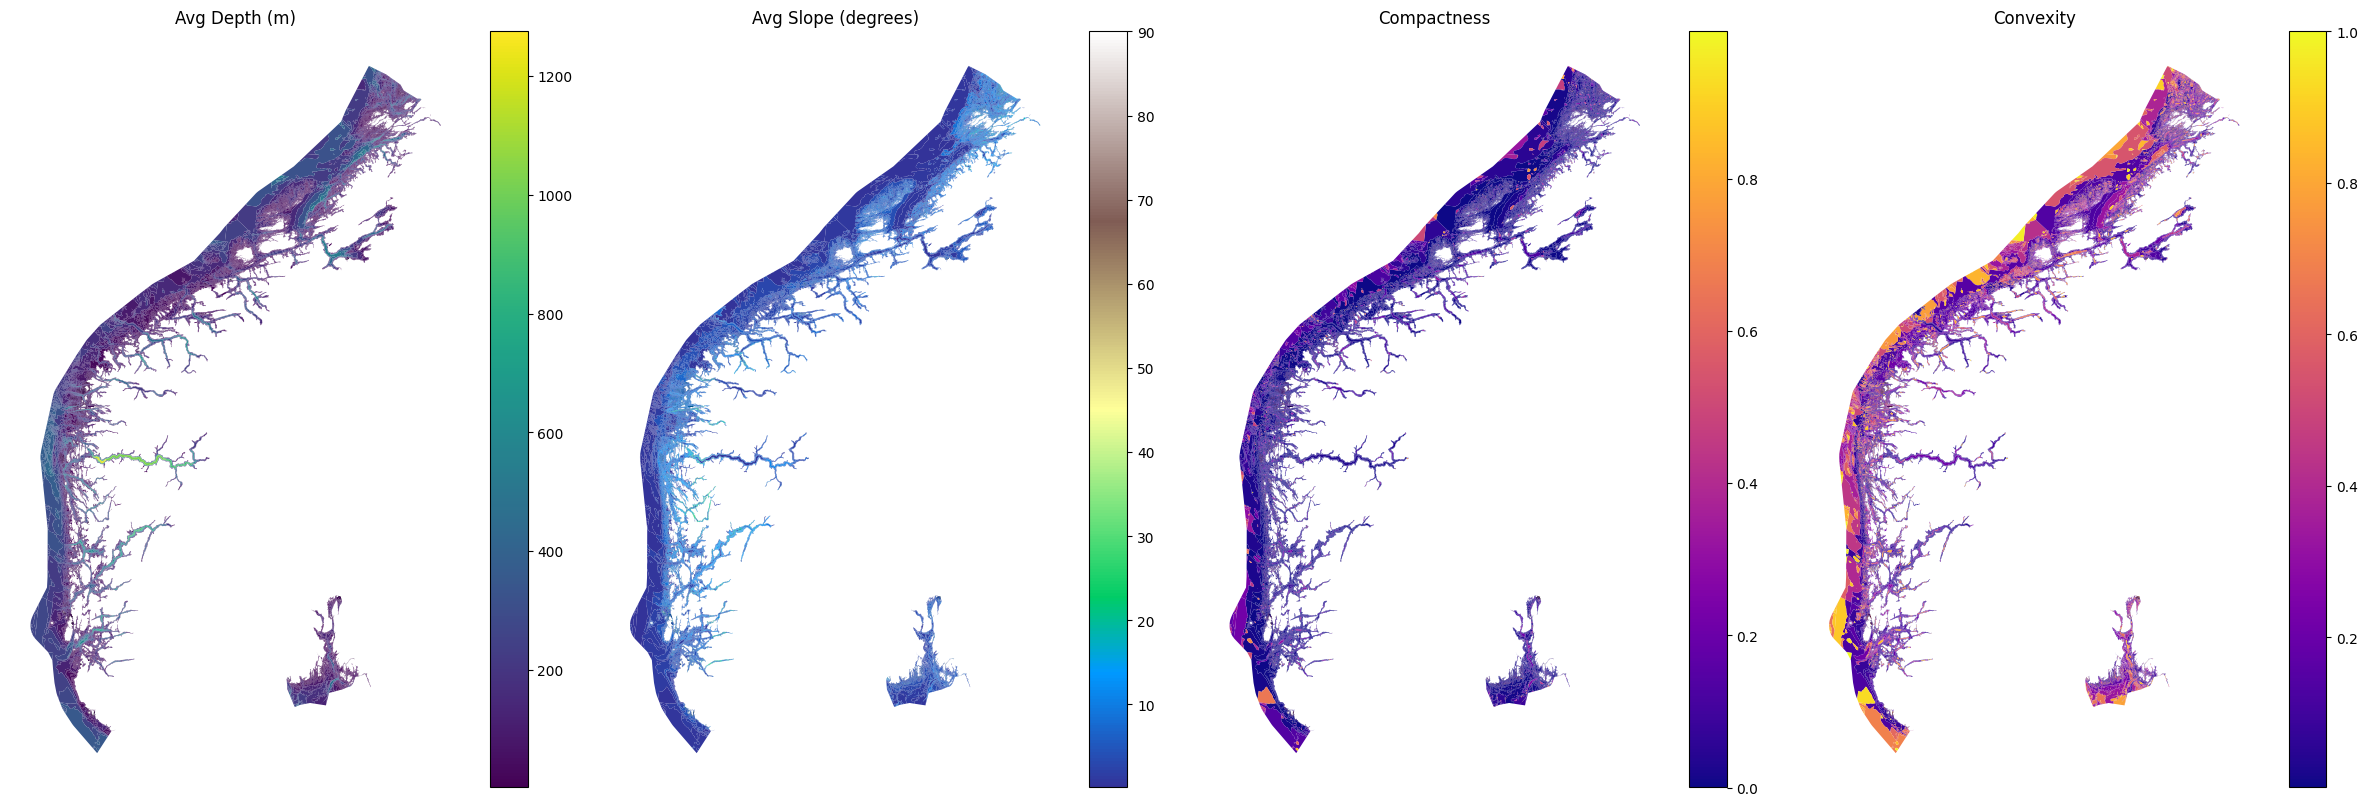

In [5]:
subkart.plot.terrain_features(gdf_sea_map)

## DEM 50

https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-50-meters-grid/67a3a191-49cc-45bc-baf0-eaaf7c513549

In [6]:
dem = subkart.sources.dem_data()

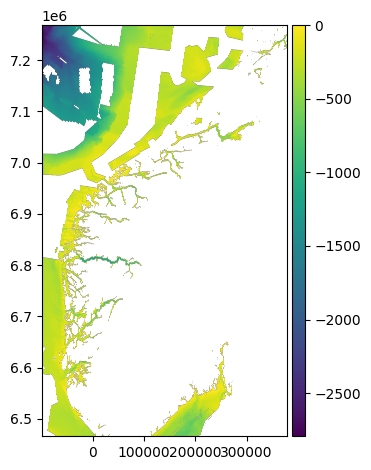

In [7]:
dem = dem.crop(bounds)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)
dem.plot()

### Wave exposure features



In [8]:
bolge = subkart.sources.bolge_exposure()


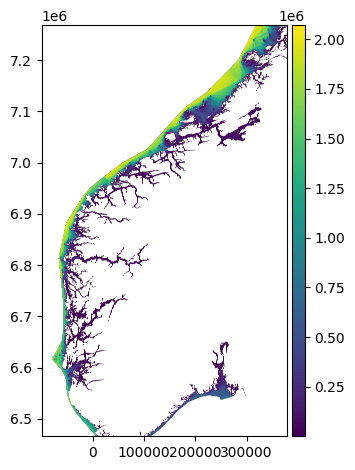

In [9]:
bolge = bolge.reproject(
    crs=crs, res=RESOLUTION,
    bounds=dict(left=bounds[0], bottom=bounds[1], right=bounds[2], top=bounds[3])
)
bolge.plot()

## Dataset for labels

In [10]:
gdf_bunn_full = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/results/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet"
)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape=out_shape, transform=transform)
del gdf_bunn_full

## Training

In [11]:
X, valid, out_shape, transform = subkart.features.build(
    dem, gdf_sea_map, bolge, valid_bunn, res=RESOLUTION, dtype=np.float32
)

Preparing sea_avg_depth...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_avg_slope...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing wave exposure...


Stacking feature arrays...


In [12]:
y = bunn_raster[valid]  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Baseline

Train a quick baseline for each model

In [13]:
baseline_models = [
    XGBClassifier(
        num_class=len(classes),
        n_estimators=300,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        tree_method="hist",
    ),
    #HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
]

score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - " f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline XGBClassifier - Train: 0.7911, Val: 0.7853


## Random Search

Search through hyperparameters for each model, this can take some time

In [14]:
is_random_search = False

if is_random_search:
    classifier = subkart.training.random_search(X_train, y_train, X_val, y_val, classes, class_weights)


In [15]:
is_xgb_random_search = True
if is_xgb_random_search:
    classifier, search_results = subkart.training.optimize_xgboost_hyperparameters(
        X_train, y_train, X_val, y_val, classes
    )

Starting search around existing parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Starting randomized search with 50 iterations and 3-fold stratified CV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


[CV] END colsample_bytree=1.0, gamma=0.49610577964560876, learning_rate=0.214097781155326, max_depth=6, min_child_weight=6, n_estimators=602, reg_alpha=0.8638900372842315, reg_lambda=1.8736874205941256, subsample=0.8447411578889519; total time=10.1min
[CV] END colsample_bytree=1.0, gamma=0.331261142176991, learning_rate=0.17740532913072932, max_depth=10, min_child_weight=6, n_estimators=455, reg_alpha=1.135400655639983, reg_lambda=1.0939398773666758, subsample=0.9369139098379995; total time= 8.7min
[CV] END colsample_bytree=1.0, gamma=0.23610746258097465, learning_rate=0.1543513095125962, max_depth=10, min_child_weight=3, n_estimators=606, reg_alpha=1.4434590423297464, reg_lambda=1.7079547592468671, subsample=0.7024273291045297; total time=16.2min


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=1.0, gamma=0.49610577964560876, learning_rate=0.214097781155326, max_depth=6, min_child_weight=6, n_estimators=602, reg_alpha=0.8638900372842315, reg_lambda=1.8736874205941256, subsample=0.8447411578889519; total time=10.1min
[CV] END colsample_bytree=1.0, gamma=0.331261142176991, learning_rate=0.17740532913072932, max_depth=10, min_child_weight=6, n_estimators=455, reg_alpha=1.135400655639983, reg_lambda=1.0939398773666758, subsample=0.9369139098379995; total time= 8.8min
[CV] END colsample_bytree=1.0, gamma=0.23610746258097465, learning_rate=0.1543513095125962, max_depth=10, min_child_weight=3, n_estimators=606, reg_alpha=1.4434590423297464, reg_lambda=1.7079547592468671, subsample=0.7024273291045297; total time=16.5min


[CV] END colsample_bytree=1.0, gamma=0.22962444598293358, learning_rate=0.18004503333668265, max_depth=7, min_child_weight=6, n_estimators=607, reg_alpha=1.4439975445336495, reg_lambda=3.8156581270472505, subsample=0.6003115063364058; total time=12.0min
[CV] END colsample_bytree=1.0, gamma=0.08263346953150125, learning_rate=0.14187636880894328, max_depth=5, min_child_weight=8, n_estimators=478, reg_alpha=0.3974313630683448, reg_lambda=1.0165663513708072, subsample=0.9261845713819337; total time= 7.0min
[CV] END colsample_bytree=1.0, gamma=0.2247253370691017, learning_rate=0.15144921397884936, max_depth=10, min_child_weight=8, n_estimators=642, reg_alpha=1.4592123566761281, reg_lambda=2.9126724140656393, subsample=0.9548850970305307; total time=12.8min
[CV] END colsample_bytree=1.0, gamma=0.48830747791632645, learning_rate=0.18932444159818776, max_depth=9, min_child_weight=1, n_estimators=475, reg_alpha=0.2897897441824462, reg_lambda=2.468358280832689, subsample=0.9942601816442402; tota

...

[CV] END colsample_bytree=1.0, gamma=0.06974693032602092, learning_rate=0.17505735782422618, max_depth=10, min_child_weight=3, n_estimators=404, reg_alpha=1.9664617716135764, reg_lambda=2.40028867974394, subsample=0.9439761626945282; total time=10.6min
[CV] END colsample_bytree=1.0, gamma=0.37366005506869043, learning_rate=0.20476305588668958, max_depth=6, min_child_weight=9, n_estimators=601, reg_alpha=1.2140684953733694, reg_lambda=1.82799754606763, subsample=0.7185094022816331; total time=10.0min
[CV] END colsample_bytree=1.0, gamma=0.46484882617128653, learning_rate=0.23697444554773006, max_depth=5, min_child_weight=5, n_estimators=483, reg_alpha=0.9130691409658205, reg_lambda=1.6553213116505008, subsample=0.7666039791481465; total time= 7.4min
[CV] END colsample_bytree=1.0, gamma=0.0002601884976579094, learning_rate=0.1823082627601003, max_depth=7, min_child_weight=7, n_estimators=547, reg_alpha=1.0214946051551315, reg_lambda=2.252233009446337, subsample=0.6888431241882922; total 

[CV] END colsample_bytree=1.0, gamma=0.33009868835886563, learning_rate=0.17359206763351315, max_depth=9, min_child_weight=7, n_estimators=541, reg_alpha=1.1087081050228014, reg_lambda=2.835162238703057, subsample=0.767840024971116; total time=12.2min
[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=10.6min


[CV] END colsample_bytree=1.0, gamma=0.34015376929388985, learning_rate=0.19405991023634517, max_depth=6, min_child_weight=4, n_estimators=438, reg_alpha=1.9312640661491187, reg_lambda=3.4251920443493833, subsample=0.7218455076693483; total time= 7.6min
[CV] END colsample_bytree=1.0, gamma=0.048836057003191935, learning_rate=0.22210796318145884, max_depth=8, min_child_weight=7, n_estimators=613, reg_alpha=0.06877704223043679, reg_lambda=3.7279612062363463, subsample=0.7035119926400069; total time=12.4min
[CV] END colsample_bytree=1.0, gamma=0.020216794769215674, learning_rate=0.2252795467622945, max_depth=6, min_child_weight=3, n_estimators=412, reg_alpha=1.7915271913470387, reg_lambda=2.4261106695463353, subsample=0.8253102287905535; total time= 6.8min
[CV] END colsample_bytree=1.0, gamma=0.44164012945943415, learning_rate=0.17892140252063288, max_depth=8, min_child_weight=9, n_estimators=580, reg_alpha=1.813656883091508, reg_lambda=1.816396748153906, subsample=0.8590760482165449; tot

[CV] END colsample_bytree=1.0, gamma=0.017971136898371043, learning_rate=0.19587176217589522, max_depth=10, min_child_weight=6, n_estimators=407, reg_alpha=0.06100049987809886, reg_lambda=1.1120445662476433, subsample=0.9290402242638633; total time=10.0min
[CV] END colsample_bytree=1.0, gamma=0.33009868835886563, learning_rate=0.17359206763351315, max_depth=9, min_child_weight=7, n_estimators=541, reg_alpha=1.1087081050228014, reg_lambda=2.835162238703057, subsample=0.767840024971116; total time=12.4min
[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=10.1min



Optimization complete!
Best CV score: 0.8106
CV train score: 0.8649
Train accuracy: 0.8552
Validation accuracy: 0.8141
Overfitting gap (train - val): 0.0411

Best parameters:
  colsample_bytree: 1.0
  gamma: 0.25440703841938
  learning_rate: 0.21635991418230746
  max_depth: 10
  min_child_weight: 6
  n_estimators: 579
  reg_alpha: 0.7861954493335208
  reg_lambda: 3.67613966553134
  subsample: 0.8524554503989052


In [16]:
dump(classifier, subkart.utils.model_dir_path() / "classifier.joblib")

['/home/jovyan/marint-naturkart-niva/model/classifier.joblib']

dem_depth: mean=0.135263, std=0.000304
wave_exposure: mean=0.119520, std=0.000469
dem_curvature: mean=0.083662, std=0.000511
dem_slope: mean=0.075142, std=0.000370
sea_avg_depth: mean=0.066756, std=0.000366
sea_convexity: mean=0.061409, std=0.000377
sea_avg_slope: mean=0.057948, std=0.000400
sea_compactness: mean=0.052309, std=0.000368
is_dem: mean=0.002348, std=0.000065


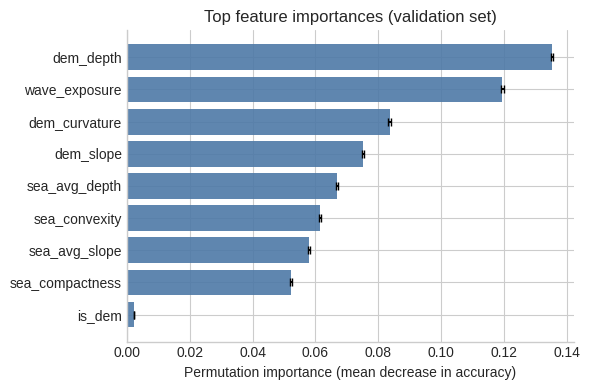

In [17]:
subkart.plot.feature_importance(classifier, X_val, y_val)

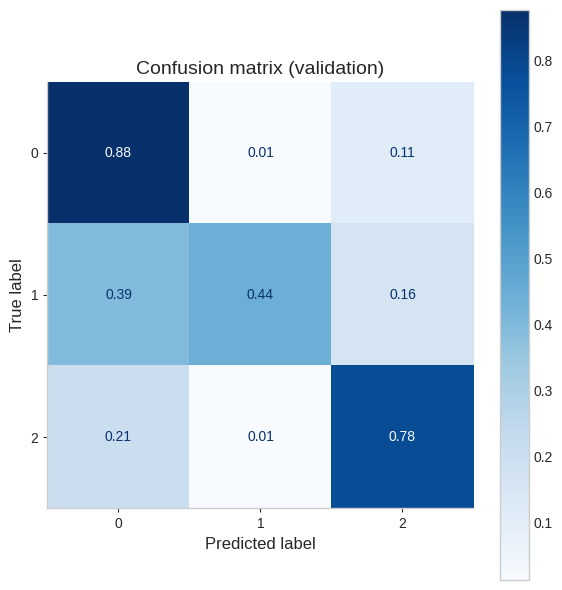

In [18]:
# Predict on validation set
y_val_pred = classifier.predict(X_val)

# Compute confusion matrix (normalized by true class)
cm = confusion_matrix(y_val, y_val_pred, labels=classes, normalize="true")

subkart.plot.confusion_matrix(cm, classes)

In [19]:
# Print classification report
print("Classification report (validation):")
report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=classes,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df


Classification report (validation):


,precision,recall,f1-score,support
0,0.842685,0.876067,0.859052,324434.000000
1,0.699170,0.441419,0.541171,36061.000000
2,0.776815,0.778643,0.777728,187882.000000
accuracy,0.814106,0.814106,0.814106,0.814106
macro avg,0.772890,0.698710,0.725984,548377.000000
weighted avg,0.810680,0.814106,0.810286,548377.000000
